# London vs Seattle Rain Precipitation

## Load and explore the data

### Import the libraries

In [6]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn 
import seaborn as sns

# set the plotting style
sns.set_style("whitegrid")

### Load the data

#### Load London dataset

In [9]:
df_london = pd.read_csv("/Users/marianabutarov/Desktop/Data Science/Foundations of Data Science /Weather Project/London.csv")

#### Load Seattle dataset

In [11]:
df_seattle = pd.read_csv("/Users/marianabutarov/Desktop/Data Science/Foundations of Data Science /Weather Project/seattle_rain.csv")

### Exploring contents of the dataset

#### Use the info method to check the data types, size of the data frames, and numbers of missing values

In [14]:
df_london.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1823 entries, 0 to 1822
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1823 non-null   object 
 1   NAME     1823 non-null   object 
 2   DATE     1823 non-null   object 
 3   PRCP     1799 non-null   float64
dtypes: float64(1), object(3)
memory usage: 57.1+ KB


In [15]:
df_seattle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1658 entries, 0 to 1657
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  1658 non-null   object 
 1   NAME     1658 non-null   object 
 2   DATE     1658 non-null   object 
 3   DAPR     23 non-null     float64
 4   MDPR     23 non-null     float64
 5   PRCP     1636 non-null   float64
 6   SNOW     353 non-null    float64
 7   SNWD     66 non-null     float64
 8   WESD     15 non-null     float64
 9   WESF     28 non-null     float64
dtypes: float64(7), object(3)
memory usage: 129.7+ KB


#### Examine the STATION column 

In [17]:
df_london['STATION'].nunique()

1

In [18]:
df_seattle['STATION'].nunique()

1

#### Examine the DATE column

In [20]:
df_london['DATE']

0       2018-01-01
1       2018-01-02
2       2018-01-03
3       2018-01-04
4       2018-01-05
           ...    
1818    2022-12-27
1819    2022-12-28
1820    2022-12-29
1821    2022-12-30
1822    2022-12-31
Name: DATE, Length: 1823, dtype: object

In [21]:
df_seattle['DATE']

0         1/1/18
1         1/2/18
2         1/3/18
3         1/4/18
4         1/5/18
          ...   
1653    12/27/22
1654    12/28/22
1655    12/29/22
1656    12/30/22
1657    12/31/22
Name: DATE, Length: 1658, dtype: object

#### Convert DATE to datetime

In [23]:
df_london['DATE']=pd.to_datetime(df_london['DATE'])

In [24]:
df_seattle['DATE']=pd.to_datetime(df_seattle['DATE'])

/var/folders/j1/t6wf96vj4hq1p8zg7blqq7km0000gn/T/ipykernel_54066/2338518779.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_seattle['DATE']=pd.to_datetime(df_seattle['DATE'])


#### Checking date range

In [26]:
df_london['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

In [27]:
df_seattle['DATE'].agg(['min','max'])

min   2018-01-01
max   2022-12-31
Name: DATE, dtype: datetime64[ns]

#### Plotting the precipitation for London

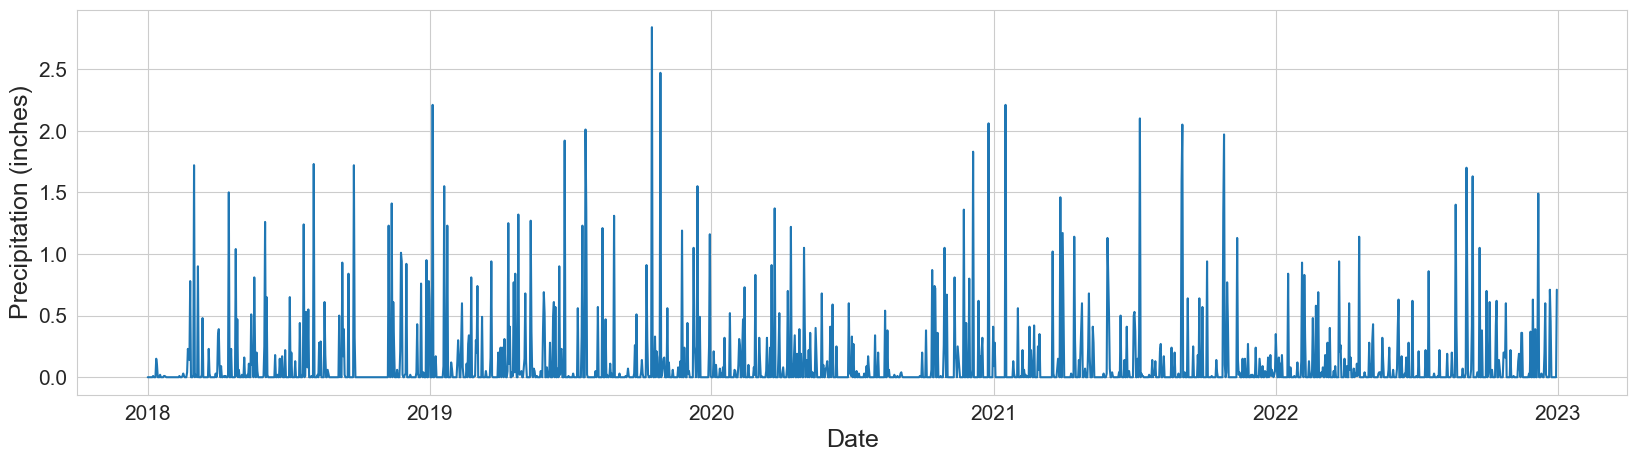

In [29]:
plt.figure(figsize=(20, 5))

sns.lineplot(data=df_london, x='DATE', y='PRCP')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

#### Plotting the precipitation for Seattle

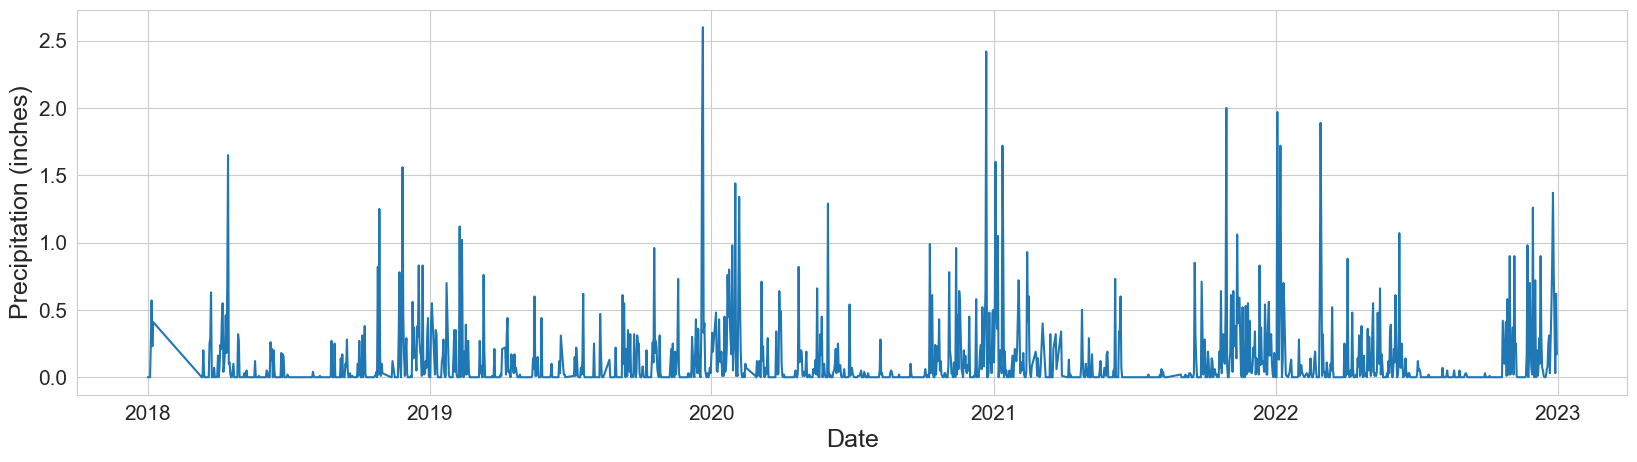

In [31]:
plt.figure(figsize=(20, 5))

sns.lineplot(data=df_seattle, x='DATE', y='PRCP')

plt.xlabel('Date', fontsize=18)
plt.ylabel('Precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

### Join data frames keeping DATE and PRCP columns

In [33]:
df = df_london[['DATE','PRCP']].merge(df_seattle[['DATE','PRCP']], on='DATE', how='outer')

In [34]:
df

,DATE,PRCP_x,PRCP_y
0,2018-01-01,0.00,0.00
1,2018-01-02,0.00,0.00
2,2018-01-03,0.00,0.00
3,2018-01-04,0.00,0.00
4,2018-01-05,NaN,0.25
...,...,...,...
1821,2022-12-27,0.00,0.78
1822,2022-12-28,0.00,0.40
1823,2022-12-29,0.00,0.03
1824,2022-12-30,0.00,0.62


In [35]:
df.describe()

,DATE,PRCP_x,PRCP_y
count,1826,1799.000000,1636.000000
mean,2020-07-01 12:00:00,0.112829,0.111852
min,2018-01-01 00:00:00,0.000000,0.000000
25%,2019-04-02 06:00:00,0.000000,0.000000
50%,2020-07-01 12:00:00,0.000000,0.010000
75%,2021-09-30 18:00:00,0.040000,0.110000
max,2022-12-31 00:00:00,2.840000,2.600000
std,NaN,0.300573,0.248635


#### Creating a tidy date frame

In [37]:
df = pd.melt(df, id_vars='DATE', var_name='city', value_name='precipitation')

In [38]:
df

,DATE,city,precipitation
0,2018-01-01,PRCP_x,0.00
1,2018-01-02,PRCP_x,0.00
2,2018-01-03,PRCP_x,0.00
3,2018-01-04,PRCP_x,0.00
4,2018-01-05,PRCP_x,NaN
...,...,...,...
3647,2022-12-27,PRCP_y,0.78
3648,2022-12-28,PRCP_y,0.40
3649,2022-12-29,PRCP_y,0.03
3650,2022-12-30,PRCP_y,0.62


In [39]:
df.describe()

,DATE,precipitation
count,3652,3435.000000
mean,2020-07-01 12:00:00,0.112364
min,2018-01-01 00:00:00,0.000000
25%,2019-04-02 00:00:00,0.000000
50%,2020-07-01 12:00:00,0.000000
75%,2021-10-01 00:00:00,0.080000
max,2022-12-31 00:00:00,2.840000
std,NaN,0.277014


#### Renaming columns values

In [41]:
df.loc[df['city']== 'PRCP_x', 'city'] = 'LDN'

In [42]:
df.loc[df['city']== 'PRCP_y', 'city'] = 'SEA'

In [43]:
df

,DATE,city,precipitation
0,2018-01-01,LDN,0.00
1,2018-01-02,LDN,0.00
2,2018-01-03,LDN,0.00
3,2018-01-04,LDN,0.00
4,2018-01-05,LDN,NaN
...,...,...,...
3647,2022-12-27,SEA,0.78
3648,2022-12-28,SEA,0.40
3649,2022-12-29,SEA,0.03
3650,2022-12-30,SEA,0.62


#### Standarzing column names

In [45]:
df = df.rename(columns={'DATE': 'date'})

In [46]:
df.head()

,date,city,precipitation
0,2018-01-01,LDN,0.0
1,2018-01-02,LDN,0.0
2,2018-01-03,LDN,0.0
3,2018-01-04,LDN,0.0
4,2018-01-05,LDN,NaN


### Identify and fill in missing values

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  3435 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 85.7+ KB


In [49]:
df.notna().sum()

date             3652
city             3652
precipitation    3435
dtype: int64

In [50]:
df.isna().sum()

date               0
city               0
precipitation    217
dtype: int64

In [51]:
df.loc[df['city'] == 'LDN', 'precipitation'].isna().sum()

27

In [52]:
df.loc[df['city'] == 'SEA', 'precipitation'].isna().sum()

190

#### Impute missing values

##### We will replace missing values with the mean across years of values on that day.


#### Defining a column that labels each day by day of the year

In [56]:
df['day_of_year'] = pd.DatetimeIndex(df['date']).day_of_year

#### Compute the mean precipitation for each day in London, averaged across years.

In [58]:
mean_day_precipitation_london=df.loc[
    df['city']=='LDN',
    ['precipitation','day_of_year']
].groupby(
    'day_of_year'
).mean()

In [59]:
mean_day_precipitation_london

,precipitation
day_of_year,
1,0.214
2,0.086
3,0.000
4,0.042
5,0.605
...,...
362,0.196
363,0.050
364,0.236


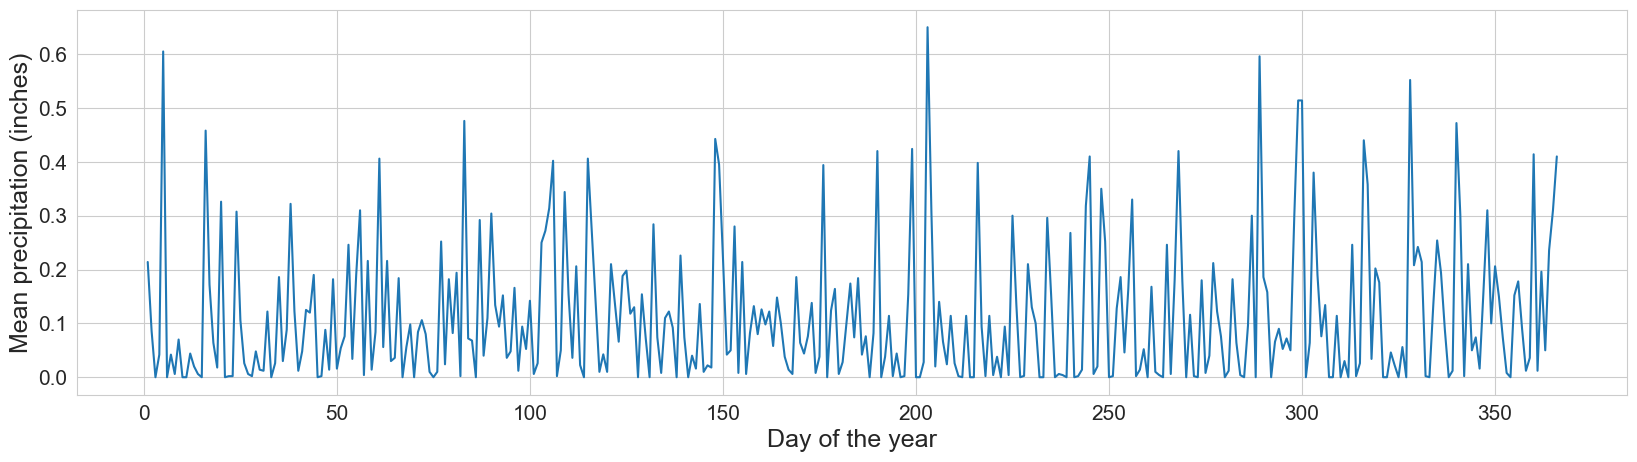

In [60]:
plt.figure(figsize=(20,5))

sns.lineplot(data=mean_day_precipitation_london, x='day_of_year', y='precipitation')

plt.xlabel('Day of the year', fontsize=18)
plt.ylabel('Mean precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

#### Compute the mean precipitation for each day in Seattle, averaged across years.

In [62]:
mean_day_precipitation_seattle=df.loc[
    df['city']=='SEA',
    ['precipitation','day_of_year']
].groupby(
    'day_of_year'
).mean()

In [63]:
mean_day_precipitation_seattle

,precipitation
day_of_year,
1,0.052000
2,0.150000
3,0.836000
4,0.370000
5,0.246667
...,...
362,0.120000
363,0.102000
364,0.268000


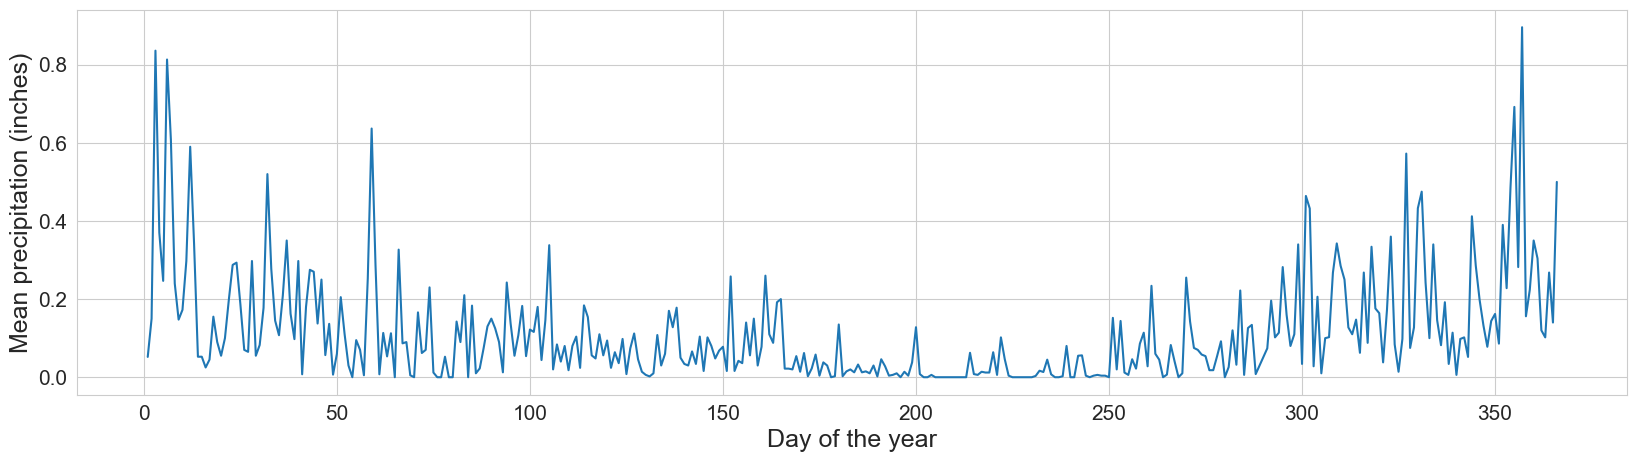

In [64]:
plt.figure(figsize=(20,5))

sns.lineplot(data=mean_day_precipitation_seattle, x='day_of_year', y='precipitation')

plt.xlabel('Day of the year', fontsize=18)
plt.ylabel('Mean precipitation (inches)', fontsize=18)

plt.tick_params(labelsize=15)

plt.show()

#### Get the index of each row where precipitation is missing.

In [66]:
indices_london = np.where(
    (df['city'] == 'LDN') & (df['precipitation'].isna())
)[0]

In [67]:
indices_london

array([   4,   23,   35,   38,   98,  147,  148,  275,  293,  294,  296,
        300,  306,  307,  310,  406,  991, 1050, 1051, 1208, 1209, 1321,
       1322, 1323, 1380, 1533, 1579])

In [68]:
indices_seattle = np.where(
    (df['city'] == 'SEA') & (df['precipitation'].isna())
)[0]

In [69]:
indices_seattle

array([1834, 1835, 1836, 1837, 1838, 1839, 1840, 1841, 1842, 1843, 1844,
       1845, 1846, 1847, 1848, 1849, 1850, 1851, 1852, 1853, 1854, 1855,
       1856, 1857, 1858, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1866,
       1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875, 1876, 1877,
       1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888,
       1889, 1890, 1891, 1892, 1893, 1894, 1895, 2090, 2131, 2132, 2133,
       2134, 2135, 2136, 2137, 2138, 2139, 2140, 2195, 2196, 2197, 2214,
       2215, 2244, 2245, 2246, 2247, 2248, 2249, 2286, 2287, 2288, 2362,
       2363, 2368, 2369, 2370, 2371, 2372, 2373, 2374, 2375, 2376, 2377,
       2417, 2418, 2419, 2420, 2421, 2422, 2423, 2517, 2518, 2519, 2520,
       2521, 2522, 2523, 2524, 2559, 2560, 2561, 2602, 2603, 2604, 2605,
       2606, 2607, 2608, 2609, 2610, 2611, 2612, 2818, 2819, 2820, 2821,
       2822, 2823, 2824, 2825, 2826, 2827, 2972, 2973, 2974, 2975, 2983,
       2984, 2986, 2987, 2988, 3000, 3001, 3004, 30

#### Replace each missing value with the mean on that day

#### Replacing for London

In [72]:
for index in indices_london:
    df.loc[index,'precipitation'] = mean_day_precipitation_london.loc[df.loc[index, 'day_of_year']].values[0]

#### Replacing for Seattle

In [74]:
for index in indices_seattle:
    df.loc[index,'precipitation'] = mean_day_precipitation_seattle.loc[df.loc[index, 'day_of_year']].values[0]

#### Checking for the null values

In [76]:
df.isna().sum()

date             0
city             0
precipitation    0
day_of_year      0
dtype: int64

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3652 entries, 0 to 3651
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           3652 non-null   datetime64[ns]
 1   city           3652 non-null   object        
 2   precipitation  3652 non-null   float64       
 3   day_of_year    3652 non-null   int32         
dtypes: datetime64[ns](1), float64(1), int32(1), object(1)
memory usage: 100.0+ KB


In [78]:
sum_london = df.loc[df['city'] == 'LDN', 'precipitation'].sum()

print(sum_london)

205.615


In [79]:
sum_seattle = df.loc[df['city'] == 'SEA', 'precipitation'].sum()

print(sum_seattle)

206.83166666666668


In [80]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year

yearly_precipitation = df.groupby(['year', 'city'])['precipitation'].sum()

print(yearly_precipitation)

year  city
2018  LDN     39.217500
      SEA     37.244167
2019  LDN     54.525000
      SEA     38.653333
2020  LDN     36.360000
      SEA     43.221667
2021  LDN     38.550000
      SEA     44.434167
2022  LDN     36.962500
      SEA     43.278333
Name: precipitation, dtype: float64


#### Export the clean .csv file

In [82]:
df.to_csv('clean_seattle_london_weather.csv', encoding='utf-8-sig', index=False)

In [83]:
x = ['a', 'b', 'c']
y = x[:]
print(x == y, x is y)

True False


Write one line of code that prints exactly this message, including both kinds of quote marks:

He said: "don't go!"

In [85]:
print('He said: "don\'t go!"')


He said: "don't go!"


In [86]:
print(True or False and False)   


True


And has higher precedence than or. so it will check false and false, which is false, true or false is true.

In [88]:
print((True or False) and False)

False


this will make what is inside the parenthesis get solved first.. True or false is true, true and false is false. 

5, it aligns the binary digits of 6 and 3 because 6 is 0110 in binary, and 3 is 0011 in binary. When you do the XOR operation, it compares if the bits return 1 when they are not the same. So the result is 0101 which in decimal is translated to 5.

0110

0011

———

0101

Use the notebook techniques from this week for listing an object’s methods and reading a docstring (dir, help, or Shift+Tab) to find a string method that replaces one piece of text with another.

x = 'mississippi'

# produce: 'mippippippi'

In [92]:
x = 'mississippi'
print(dir(x))

['__add__', '__class__', '__contains__', '__delattr__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__len__', '__lt__', '__mod__', '__mul__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__rmod__', '__rmul__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', 'capitalize', 'casefold', 'center', 'count', 'encode', 'endswith', 'expandtabs', 'find', 'format', 'format_map', 'index', 'isalnum', 'isalpha', 'isascii', 'isdecimal', 'isdigit', 'isidentifier', 'islower', 'isnumeric', 'isprintable', 'isspace', 'istitle', 'isupper', 'join', 'ljust', 'lower', 'lstrip', 'maketrans', 'partition', 'removeprefix', 'removesuffix', 'replace', 'rfind', 'rindex', 'rjust', 'rpartition', 'rsplit', 'rstrip', 'split', 'splitlines', 'startswith', 'strip', 'swapcase', 'title', 'translate', 'upper', 'zfill']


In [93]:
x.replace('ssi','ppi')

'mippippippi'

This question asks you to explore something on your own. Read the docstring for a list’s copy() method (Shift+Tab).

z = ['p', ['q', 'r'], 's']
y = z.copy()
z[1].append('t')

print(z is y)
print(z == y)
Give the output of both print statements and explain why. Your explanation should say what copy() duplicated and what it did not.

In [160]:
z = ['p', ['q', 'r'], 's']
print (z)
y = z.copy()
print (y)
z[1].append('t')
z.append('m')
print (z)
print(y)
print(z is y) 
print(z == y)

['p', ['q', 'r'], 's']
['p', ['q', 'r'], 's']
['p', ['q', 'r', 't'], 's', 'm']
['p', ['q', 'r', 't'], 's']
False
False
